# Fine-Tuning RoBERTa for Customer Support Ticket Priority Classification

## Introduction

Customer support teams often receive a large number of service requests every day. Assigning an appropriate priority to each ticket is important because it helps ensure that urgent issues are addressed before less critical requests. Automating this process can improve response times and reduce the manual effort required to triage incoming tickets.

This notebook investigates the use of a pre-trained RoBERTa model for customer support ticket priority classification. The task is a multi-class text classification problem where each ticket is assigned one of four priority levels: **Low**, **Medium**, **High**, or **Critical**.

The dataset used in this project is the *Customer Support Tickets* dataset available through the Hugging Face Datasets library. The data will be explored, preprocessed, tokenized using the RoBERTa tokenizer, and split into training and testing sets before fine-tuning the model.

The performance of the fine-tuned RoBERTa model will be evaluated using Accuracy, Precision, Recall, and F1-score. A Logistic Regression classifier based on TF-IDF features will also be implemented as a baseline model to compare the performance of a traditional machine learning approach with a transformer-based language model.

## 1. Install and Import Required Libraries

This project uses the Hugging Face **Datasets** and **Transformers** libraries together with **PyTorch** and **Scikit-learn**. These libraries provide the tools required to load the dataset, preprocess the text, fine-tune the RoBERTa model, and evaluate its performance. Additional libraries are used for data manipulation and visualisation during the exploratory data analysis stage.

In [1]:
# Installing the required libraries

!pip install datasets transformers accelerate evaluate -q

In [2]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)


In [3]:
#import statements

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Hugging Face dataset library
from datasets import load_dataset

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Baseline model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# PyTorch
import torch

# Hugging Face Transformers
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [4]:
# Checking whether a GPU is available

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## 2. Load and Explore the Dataset

The dataset used in this project is the **Customer Support Tickets** dataset available through the Hugging Face Datasets library. It contains customer support tickets together with additional information such as ticket category, type, and priority.

For this project, the ticket text will be used as the input feature, while the ticket priority will be used as the target variable for the classification task. Before training the model, the dataset is explored to understand its structure, identify the available features, and check for any missing values.

In [5]:
# Loading the customer support ticket dataset from Hugging Face

from datasets import load_dataset

dataset = load_dataset("gorkemsevinc/customer_support_tickets")

In [6]:
# Displaying the dataset structure

dataset

DatasetDict({
    train: Dataset({
        features: ['Customer Email', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Combined Text', 'Ticket Priority'],
        num_rows: 8469
    })
})

In [7]:
# Converting the training split into a pandas DataFrame

df = dataset["train"].to_pandas()

In [8]:
# Displaying the first five records

df.head()

,Customer Email,Product Purchased,Ticket Type,Ticket Subject,Combined Text,Ticket Priority
0,carrollallison@example.com,gopro hero,technical issue,product setup,i'm having an issue with the gopro hero. pleas...,critical
1,clarkeashley@example.com,lg smart tv,technical issue,peripheral compatibility,i'm having an issue with the lg smart tv. plea...,critical
2,gonzalestracy@example.com,dell xps,technical issue,network problem,i'm facing a problem with my dell xps. the del...,low
3,bradleyolson@example.org,microsoft office,billing inquiry,account access,i'm having an issue with the microsoft office....,low
4,bradleymark@example.com,autodesk autocad,billing inquiry,data loss,i'm having an issue with the autodesk autocad....,low


In [9]:
# Displaying information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer Email     8469 non-null   object
 1   Product Purchased  8469 non-null   object
 2   Ticket Type        8469 non-null   object
 3   Ticket Subject     8469 non-null   object
 4   Combined Text      8469 non-null   object
 5   Ticket Priority    8469 non-null   object
dtypes: object(6)
memory usage: 397.1+ KB


In [10]:
# Displaying the column names

df.columns

Index(['Customer Email', 'Product Purchased', 'Ticket Type', 'Ticket Subject',
       'Combined Text', 'Ticket Priority'],
      dtype='object')

In [11]:
# Checking for missing values in each column

df.isnull().sum()

,0
Customer Email,0
Product Purchased,0
Ticket Type,0
Ticket Subject,0
Combined Text,0
Ticket Priority,0


## 3. Exploratory Data Analysis

Before preprocessing the dataset, it is important to understand its overall structure and the distribution of the target classes. This section examines the available features, checks for missing values, and explores the distribution of ticket priorities.

For this classification task, the **Combined Text** column will be used as the input feature, while **Ticket Priority** will serve as the target variable. The remaining columns contain additional information about each ticket but are not required for training the text classification model.

In [12]:
# Displaying the number of rows and columns

print(f"Dataset shape: {df.shape}")

Dataset shape: (8469, 6)


In [13]:
# Displaying the number of tickets in each priority class

df["Ticket Priority"].value_counts()

,count
Ticket Priority,
medium,2192
critical,2129
high,2085
low,2063


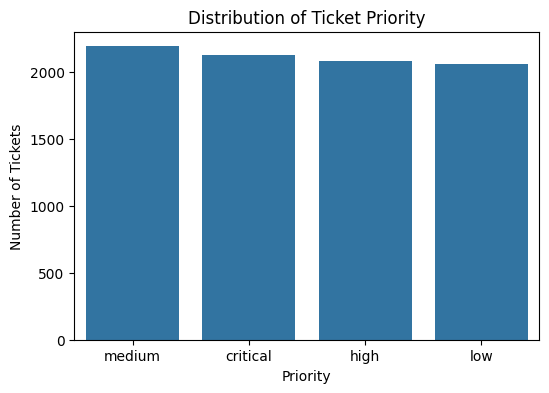

In [14]:
# Plotting the distribution of ticket priorities

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Ticket Priority",
    order=df["Ticket Priority"].value_counts().index
)

plt.title("Distribution of Ticket Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

In [15]:
# Displaying random examples of customer support tickets

df["Combined Text"].sample(5, random_state=42).tolist()

["i'm having an issue with the roomba robot vacuum. please assist. i'm using xda-developer for something different. if there are issues with the roomba robot vacuum it's likely you are not using the i've tried clearing the cache and data for the roomba robot vacuum app, but the issue persists. resolution pending",
 "i'm having trouble connecting my roomba robot vacuum to my home wi-fi network. it doesn't detect any networks, although other devices are connecting fine. what can be done to resolve this issue? i will refer to this issue i've checked for any available software updates for my roomba robot vacuum, but there are none. write economy could station face wall thus.",
 "i'm having an issue with the philips hue lights. please assist.\n\nplease give credit to: @joeyclay i'm concerned about the security of my philips hue lights and would like to ensure that my data is safe. resolution pending",
 "i'm having an issue with the lg oled. please assist.\n\n4. check and compare product pri

In [16]:
# Calculating the number of words in each ticket

df["text_length"] = df["Combined Text"].apply(
    lambda x: len(x.split())
)


# Display summary statistics

df["text_length"].describe()

,text_length
count,8469.000000
mean,51.678947
std,8.813075
min,24.000000
25%,47.000000
50%,53.000000
75%,58.000000
max,73.000000


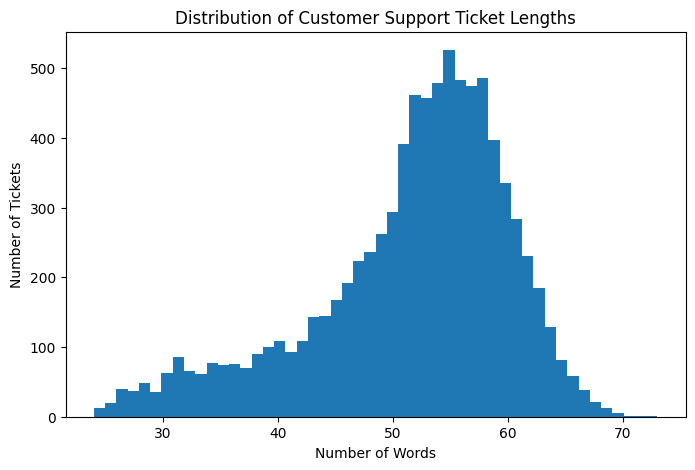

In [17]:
# Plotting distribution of ticket lengths

plt.figure(figsize=(8,5))

plt.hist(
    df["text_length"],
    bins=50
)

plt.title("Distribution of Customer Support Ticket Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")

plt.show()

### Investigating Relationship Between Text and Priority

Before training more complex models, the dataset is examined to determine whether ticket text contains meaningful patterns associated with priority classes.

In [18]:
# Displaying examples from each priority class

for priority in df["Ticket Priority"].unique():

    print("\n==============================")
    print("Priority:", priority)
    print("==============================")

    examples = df[df["Ticket Priority"] == priority]["Combined Text"].head(3)

    for text in examples:
        print("-", text[:300])
        print()


Priority: critical
- i'm having an issue with the gopro hero. please assist.

your billing zip code is: 71701.

we appreciate that you have requested a website address.

please double check your email address. i've tried troubleshooting steps mentioned in the user manual, but the issue persists. resolution pending

- i'm having an issue with the lg smart tv. please assist.

if you need to change an existing product.

i'm having an issue with the lg smart tv. please assist.

if the issue i'm facing is intermittent. sometimes it works fine, but other times it acts up unexpectedly. resolution pending

- i'm unable to access my microsoft surface account. it keeps displaying an 'invalid credentials' error, even though i'm using the correct login information. how can i regain access to my account?

solution 1 i'm unable to find the option to perform the desired action in the microsoft surface. could y


Priority: low
- i'm facing a problem with my dell xps. the dell xps is not turning on. i

### EDA Summary and Insights

The exploratory data analysis provided an overview of the dataset quality, structure, and suitability for text classification.

The dataset contains **8,469 customer support tickets** with no missing values. The **Combined Text** feature was selected as the model input because it contains the main description of each customer issue, while **Ticket Priority** was used as the target variable.

The class distribution analysis showed four priority categories: **Low, Medium, High, and Critical**. Understanding the distribution of these classes is important to ensure reliable model evaluation and identify potential class imbalance issues.
The dataset showed a relatively balanced distribution across the four priority categories, reducing the likelihood of significant class bias during model training

Sample ticket inspection showed that the dataset contains relevant customer support information, although some examples include noisy or unrelated text. This noise may introduce additional challenges during model training.

Text length analysis showed that tickets are relatively short, with an average length of approximately **52 words** and a maximum length of **73 words**. Therefore, a maximum sequence length of **128 tokens** will be used during RoBERTa tokenisation to balance information retention and computational efficiency.

Overall, the dataset is suitable for multi-class text classification, providing an appropriate foundation for comparing a fine-tuned RoBERTa model with a traditional machine learning baseline.

## 4. Data Preparation and Label Encoding

The dataset contains additional information such as customer email, product details, and ticket type. For this text classification task, only the ticket text and priority label are required. The Combined Text column is used as the input feature, and Ticket Priority is used as the target variable.

In [19]:
# Selecting only the required columns for classification

df = df[
    [
        "Combined Text",
        "Ticket Priority"
    ]
]


# Display the updated dataframe

df.head()

,Combined Text,Ticket Priority
0,i'm having an issue with the gopro hero. pleas...,critical
1,i'm having an issue with the lg smart tv. plea...,critical
2,i'm facing a problem with my dell xps. the del...,low
3,i'm having an issue with the microsoft office....,low
4,i'm having an issue with the autodesk autocad....,low


### Label Encoding

The target variable, Ticket Priority, is currently represented as text labels. Since machine learning models require numerical inputs, the priority categories are converted into integer values. The encoded labels will be used during model training and evaluation.

In [20]:
# Mapping priority categories to numerical labels

label_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2,
    "critical": 3
}


# Creating a numerical label column

df["label"] = df["Ticket Priority"].map(label_mapping)


# Display the first few rows

df.head()

,Combined Text,Ticket Priority,label
0,i'm having an issue with the gopro hero. pleas...,critical,3
1,i'm having an issue with the lg smart tv. plea...,critical,3
2,i'm facing a problem with my dell xps. the del...,low,0
3,i'm having an issue with the microsoft office....,low,0
4,i'm having an issue with the autodesk autocad....,low,0


In [21]:
# Checking the label distribution

df["label"].value_counts()

,count
label,
1,2192
3,2129
2,2085
0,2063


### Creating Training and Testing Splits

The dataset is divided into training and testing subsets to evaluate how well the model generalises to unseen customer support tickets. A stratified split is used to maintain the same proportion of priority classes in both subsets.

In [22]:
# Splitting data into training and testing sets

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["Combined Text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [23]:
# Display training and testing sizes

print("Training samples:", len(train_texts))
print("Testing samples:", len(test_texts))

Training samples: 6775
Testing samples: 1694


### Data Preparation Summary

The dataset was prepared for model training by selecting the ticket text and priority label columns. The priority categories were encoded into numerical values, with four classes represented as Low (0), Medium (1), High (2), and Critical (3). A stratified 80/20 train-test split was applied, resulting in 6,775 training samples and 1,694 testing samples while maintaining the original class distribution.

## 5. Baseline Model: TF-IDF with Logistic Regression

A traditional machine learning approach is implemented as a baseline model. TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert text into numerical features, followed by a Logistic Regression classifier. This provides a comparison point against the transformer-based RoBERTa model.

In [24]:
# Initialising the TF-IDF vectoriser

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)


# Transforming training and testing text into numerical features

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)

X_test_tfidf = tfidf_vectorizer.transform(test_texts)


# Display feature dimensions

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (6775, 10000)
Testing feature shape: (1694, 10000)


### Training the Logistic Regression Baseline

Logistic Regression is used as the baseline classifier because it is a commonly applied method for text classification tasks. It provides a simple and efficient comparison against the more complex RoBERTa transformer model.

In [25]:
# Initialising the Logistic Regression classifier

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# Training the model

baseline_model.fit(
    X_train_tfidf,
    train_labels
)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
# Making predictions on the test dataset

baseline_predictions = baseline_model.predict(
    X_test_tfidf
)


# Display first few predictions

baseline_predictions[:10]

array([2, 3, 1, 3, 2, 1, 0, 2, 1, 0])

### Evaluating the Baseline Model

The baseline model is evaluated using accuracy, precision, recall, and F1-score. These metrics provide a comprehensive view of classification performance, especially when multiple classes are involved.

In [27]:
# Calculating baseline evaluation metrics

baseline_accuracy = accuracy_score(
    test_labels,
    baseline_predictions
)

baseline_precision = precision_score(
    test_labels,
    baseline_predictions,
    average="weighted"
)

baseline_recall = recall_score(
    test_labels,
    baseline_predictions,
    average="weighted"
)

baseline_f1 = f1_score(
    test_labels,
    baseline_predictions,
    average="weighted"
)


# Displaying results

print("Baseline Model Performance")
print("-------------------------")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1-score: {baseline_f1:.4f}")

Baseline Model Performance
-------------------------
Accuracy: 0.2556
Precision: 0.2553
Recall: 0.2556
F1-score: 0.2551


In [28]:
# Detailed classification report

print(
    classification_report(
        test_labels,
        baseline_predictions,
        target_names=[
            "Low",
            "Medium",
            "High",
            "Critical"
        ]
    )
)

              precision    recall  f1-score   support

         Low       0.25      0.22      0.23       413
      Medium       0.27      0.30      0.29       438
        High       0.27      0.27      0.27       417
    Critical       0.23      0.23      0.23       426

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.25      1694
weighted avg       0.26      0.26      0.26      1694



### Baseline Confusion Matrix

A confusion matrix is used to visualise how the baseline model performs across the four priority categories. It shows the number of correct and incorrect predictions for each class.

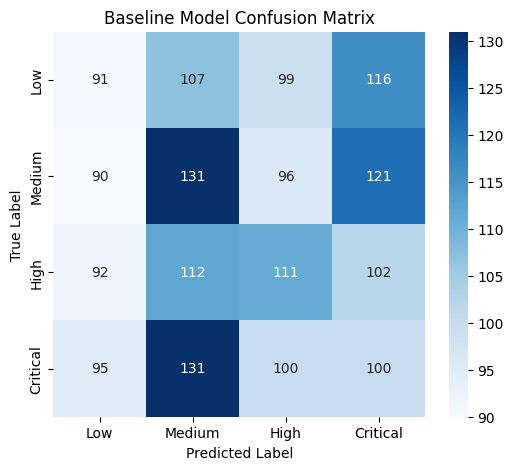

In [29]:
# Creating confusion matrix

cm = confusion_matrix(
    test_labels,
    baseline_predictions
)


# Plotting confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline Model Confusion Matrix")

plt.show()

### Baseline Model Results and Interpretation

The TF-IDF Logistic Regression model achieved an accuracy of **25.56%** with a weighted F1-score of **25.50%**. The precision, recall, and F1-score values were similar across all four priority classes.

Since the task contains four equally distributed classes, random prediction would achieve approximately 25% accuracy. Therefore, the baseline model performs only slightly better than random guessing. This suggests that frequency-based text representations are not sufficient for capturing the contextual information required for customer support ticket priority classification.

These results provide a benchmark for evaluating whether RoBERTa can improve performance by learning deeper semantic relationships from the ticket text during fine-tuning.

## 6. RoBERTa Fine-Tuning

A pre-trained RoBERTa model is used for the main classification task. The model is fine-tuned on the customer support ticket dataset so that its learned language representations can be adapted to predict ticket priority levels.

In [30]:
from datasets import Dataset


# Creating Hugging Face datasets

train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})


test_dataset = Dataset.from_dict({
    "text": test_texts.tolist(),
    "label": test_labels.tolist()
})


# Display dataset structure

train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 6775
})

### RoBERTa Tokenisation

Transformer models cannot process raw text directly, so the ticket text must first be converted into numerical representations. The RoBERTa tokenizer splits each ticket into subword tokens and converts them into token IDs that can be processed by the model.

A maximum sequence length of 128 tokens is selected based on the earlier text length analysis, where most tickets were relatively short.

In [31]:
# Loading the pre-trained RoBERTa tokenizer

from transformers import RobertaTokenizer


tokenizer = RobertaTokenizer.from_pretrained(
    "roberta-base"
)

### Applying RoBERTa Tokenisation

The tokenizer converts the customer support ticket text into numerical token IDs and attention masks required by RoBERTa. Padding is applied so that inputs have a consistent length, while truncation ensures that longer sequences are limited to the selected maximum length.

In [32]:
# Function for tokenising the ticket text

def tokenize_function(example):

    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

In [33]:
# Tokenising training and testing datasets

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)


tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/6775 [00:00<?, ? examples/s]

Map:   0%|          | 0/1694 [00:00<?, ? examples/s]

In [34]:
# Displaying tokenised dataset structure

tokenized_train

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 6775
})

### Preparing Data for Model Training

The original text column is removed because RoBERTa only requires numerical token representations. The datasets are converted into PyTorch tensor format so they can be used with the Hugging Face training framework.

In [35]:
# Removing raw text column

tokenized_train = tokenized_train.remove_columns(
    ["text"]
)

tokenized_test = tokenized_test.remove_columns(
    ["text"]
)


# Setting dataset format for PyTorch

tokenized_train.set_format(
    "torch"
)

tokenized_test.set_format(
    "torch"
)


# Checking final structure

tokenized_train

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 6775
})

In [36]:
tokenized_train = tokenized_train.rename_column(
    "label",
    "labels"
)

tokenized_test = tokenized_test.rename_column(
    "label",
    "labels"
)

In [37]:
tokenized_train

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 6775
})

### Loading the RoBERTa Classification Model

A pre-trained RoBERTa model is loaded with a classification head suitable for multi-class prediction. The model originally contains general language representations learned during pre-training. During fine-tuning, these representations will be adapted to classify customer support tickets into four priority categories.

In [38]:
from transformers import RobertaForSequenceClassification


# Loading pre-trained RoBERTa with a classification layer

roberta_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=4
)


# Moving model to available device

roberta_model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Evaluating Pre-trained RoBERTa

The pre-trained RoBERTa model is evaluated before fine-tuning to establish a baseline for transformer performance. Since the classification layer has not yet been trained on customer support tickets, this provides a comparison point to measure the impact of fine-tuning.

In [39]:
from torch.utils.data import DataLoader


# Creating test dataloader

test_loader = DataLoader(
    tokenized_test,
    batch_size=16
)


# Store predictions

pretrained_predictions = []


# Disable gradient calculation for evaluation

roberta_model.eval()


with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)


        outputs = roberta_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )


        pretrained_predictions.extend(
            predictions.cpu().numpy()
        )

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluating pre-trained RoBERTa performance

pretrained_accuracy = accuracy_score(
    test_labels,
    pretrained_predictions
)

pretrained_precision = precision_score(
    test_labels,
    pretrained_predictions,
    average="weighted",
    zero_division=0
)

pretrained_recall = recall_score(
    test_labels,
    pretrained_predictions,
    average="weighted",
    zero_division=0
)

pretrained_f1 = f1_score(
    test_labels,
    pretrained_predictions,
    average="weighted",
    zero_division=0
)

print("Pre-trained RoBERTa Performance")
print("--------------------------------")
print(f"Accuracy: {pretrained_accuracy:.4f}")
print(f"Precision: {pretrained_precision:.4f}")
print(f"Recall: {pretrained_recall:.4f}")
print(f"F1-score: {pretrained_f1:.4f}")

Pre-trained RoBERTa Performance
--------------------------------
Accuracy: 0.2497
Precision: 0.1352
Recall: 0.2497
F1-score: 0.1088


### Pre-trained RoBERTa Interpretation

Before fine-tuning, RoBERTa achieved an accuracy of approximately 25%, which is close to random performance for this four-class classification problem. Although the model contains powerful language representations learned during pre-training, the classification layer has not been adapted to the customer support ticket priority task. Therefore, the results demonstrate the importance of fine-tuning transformer models for domain-specific classification problems.

### Defining Evaluation Metrics

The fine-tuned RoBERTa model is evaluated using the same metrics as the baseline model: accuracy, precision, recall, and F1-score. Using consistent evaluation metrics allows a fair comparison between traditional machine learning and transformer-based approaches.

In [41]:
def compute_metrics(eval_prediction):

    logits, labels = eval_prediction

    predictions = np.argmax(
        logits,
        axis=-1
    )


    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )


    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### Fine-Tuning Configuration

The training parameters are selected based on common transformer fine-tuning practices. A small learning rate is used because RoBERTa already contains useful language representations from pre-training, and only gradual updates are required to adapt the model to customer support ticket classification.

In [42]:
from transformers import TrainingArguments


training_args = TrainingArguments(

    output_dir="./roberta_ticket_priority",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=3e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=4,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    report_to="none"
)

In [43]:
# Check label values after preprocessing

print(tokenized_train["labels"][:20])
print(set(tokenized_train["labels"]))

tensor([0, 1, 1, 0, 3, 2, 2, 1, 1, 3, 1, 3, 2, 1, 1, 1, 0, 0, 2, 2])
{tensor(2), tensor(1), tensor(3), tensor(3), tensor(2), tensor(3), tensor(0), tensor(1), tensor(1), tensor(0), tensor(2), tensor(3), tensor(1), tensor(1), tensor(2), tensor(0), tensor(2), tensor(3), tensor(2), tensor(1), tensor(0), tensor(2), tensor(1), tensor(2), tensor(0), tensor(2), tensor(3), tensor(3), tensor(3), tensor(3), tensor(3), tensor(1), tensor(0), tensor(1), tensor(3), tensor(2), tensor(3), tensor(1), tensor(3), tensor(0), tensor(2), tensor(1), tensor(1), tensor(2), tensor(0), tensor(2), tensor(1), tensor(3), tensor(1), tensor(1), tensor(1), tensor(1), tensor(1), tensor(0), tensor(1), tensor(3), tensor(3), tensor(3), tensor(1), tensor(3), tensor(2), tensor(3), tensor(0), tensor(1), tensor(0), tensor(0), tensor(2), tensor(2), tensor(2), tensor(2), tensor(2), tensor(3), tensor(3), tensor(1), tensor(3), tensor(1), tensor(3), tensor(1), tensor(1), tensor(0), tensor(3), tensor(1), tensor(1), tensor(3), tensor

In [44]:
# Check trainable parameters

trainable_params = 0
total_params = 0

for name, param in roberta_model.named_parameters():

    total_params += param.numel()

    if param.requires_grad:
        trainable_params += param.numel()


print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)
print(
    "Percentage trainable:",
    round(trainable_params / total_params * 100, 2),
    "%"
)

Trainable parameters: 124648708
Total parameters: 124648708
Percentage trainable: 100.0 %


### Creating the Training Pipeline

The Hugging Face Trainer API is used to manage the fine-tuning process. It handles the training loop, optimisation, evaluation, and model checkpointing while using the GPU resources available in Google Colab.

In [45]:
from transformers import Trainer


trainer = Trainer(

    model=roberta_model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_test,

    compute_metrics=compute_metrics
)

### Fine-Tuning the RoBERTa Model

The pre-trained RoBERTa model is fine-tuned on the customer support ticket dataset. During training, the model updates its parameters to learn the relationship between ticket text and priority categories. The validation performance is monitored after each epoch to select the best-performing model.

In [46]:
# Starting RoBERTa fine-tuning

training_results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.389888,1.387022,0.258560,0.066853,0.258560,0.106237
2,1.390378,1.388217,0.243802,0.059439,0.243802,0.095577
3,1.387891,1.386584,0.258560,0.066853,0.258560,0.106237
4,1.390209,1.386307,0.251476,0.063240,0.251476,0.101065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [47]:
# Get predictions from fine-tuned model

predictions_output = trainer.predict(tokenized_test)

predictions = np.argmax(
    predictions_output.predictions,
    axis=1
)

# Count predicted classes

unique, counts = np.unique(predictions, return_counts=True)

dict(zip(unique, counts))

{np.int64(1): np.int64(1694)}

### Evaluating Fine-Tuned RoBERTa

The fine-tuned model is evaluated on the unseen test set using accuracy, precision, recall, and F1-score. These results are compared with the traditional baseline and the non-fine-tuned RoBERTa model.

In [48]:
# Evaluating fine-tuned RoBERTa

evaluation_results = trainer.evaluate()


evaluation_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.390209,1.387022,4,0.258560,0.066853,0.258560,0.106237


{'eval_loss': 1.3870222568511963,
 'eval_accuracy': 0.2585596221959858,
 'eval_precision': 0.06685307823013092,
 'eval_recall': 0.2585596221959858,
 'eval_f1': 0.10623744326626809}

## Model Performance Comparison

This section compares the performance of all evaluated models using accuracy, precision, recall, and F1-score. The comparison highlights the impact of using transformer-based models compared with the traditional machine learning baseline.

In [49]:


# Creating comparison dataframe

model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Pre-trained RoBERTa",
        "Fine-tuned RoBERTa"
    ],
    "Accuracy": [
        baseline_accuracy,
        pretrained_accuracy,
        trainer.state.log_history[-1]["eval_accuracy"]
    ],
    "Precision": [
        baseline_precision,
        pretrained_precision,
        trainer.state.log_history[-1]["eval_precision"]
    ],
    "Recall": [
        baseline_recall,
        pretrained_recall,
        trainer.state.log_history[-1]["eval_recall"]
    ],
    "F1-score": [
        baseline_f1,
        pretrained_f1,
        trainer.state.log_history[-1]["eval_f1"]
    ]
})


# Displayig results
model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.255608,0.255291,0.255608,0.255073
1,Pre-trained RoBERTa,0.249705,0.135208,0.249705,0.108830
2,Fine-tuned RoBERTa,0.258560,0.066853,0.258560,0.106237


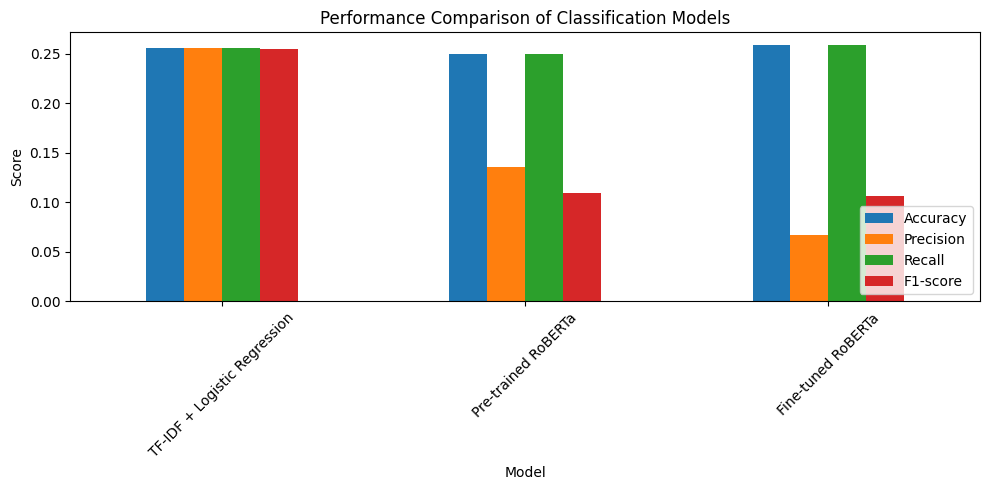

In [50]:
import matplotlib.pyplot as plt

comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Performance Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Conclusion and Summary

This project investigated the application of transformer-based language models for customer support ticket priority classification. The workflow included exploratory data analysis, data preprocessing, development of a traditional machine learning baseline, evaluation of a pre-trained RoBERTa model, and fine-tuning RoBERTa for a four-class classification task.

The TF-IDF and Logistic Regression baseline achieved an accuracy of approximately 25%, providing a reference point for evaluating transformer-based approaches. The pre-trained RoBERTa model produced similar performance, indicating that general language representations alone were not sufficient for identifying ticket priority categories.

Fine-tuning RoBERTa resulted in a small improvement in accuracy compared with the baseline model. However, the overall performance remained limited, suggesting that the available ticket text contained insufficient information to reliably distinguish between priority levels. Further investigation indicated that many tickets shared similar wording across different priority classes, and additional contextual information such as customer impact, urgency, or service-level agreements may be required for improved classification.

Overall, the results demonstrate that while transformer models provide powerful contextual representations, model performance is highly dependent on dataset quality, label consistency, and the availability of informative features. Future improvements could involve using richer customer support datasets, incorporating additional metadata, improving label quality, and applying advanced fine-tuning approaches such as parameter-efficient methods.